# Implement Prompt-Chaining Agentic Workflows With OpenAI Agents SDK and LangGraph

## Overview

**Agentic design patterns**  describe reusable architectural approaches for structuring workflows for AI agent systems, defining how an AI agent's work should be broken into steps, how decisions are made between those steps, and how information flows through the system.

When you build an AI agent system, these patterns help you decide how to organize its reasoning and actions into a clear, structured workflow.

Each agentic design pattern represents a different way of organizing agent behavior, such as sequencing steps, routing requests, executing work in parallel, or coordinating agents through orchestration and reflection. In this course, you will implement the following patterns:

- Prompt Chaining (or deterministic workflows)
- Routing
- Parallelization
- Orchestrator Workflows
- Plan Reflection (evaluator–optimizer)

For each pattern, you will first explore a complete, end-to-end example. You will then reinforce your understanding by completing an exercise that closely mirrors the example implementation.

You will implement these patterns by building working agentic workflows using both the OpenAI Agents SDK and LangGraph. However, the patterns themselves are framework-agnostic and can be applied using virtually any agent framework or builder tool, including GUI-based platforms such as `n8n.io`. As long as your chosen framework supports tooling for building effective agents, you will be able to implement these patterns in your own systems.

In this activity, you will implement prompt chaining, the most foundational agentic design pattern, by building two complete prompt chaining workflows.

## Prompt Chaining (Deterministic Workflows)

**What is Prompt Chaining?**

When designing AI workflows, the goal is usually to automate an existing process. System designers often break these workflows into smaller, well-defined tasks, even when humans are the ones performing the work. The reason is simple: Breaking a job into smaller steps makes it easier to define the constraints, the objective, the tools required, and the methods for validating the output.

Think about painting a car body. It's divided into stages:
1. **Surface Preparation**: Clean and smooth the surface (Validation: surface is free of dust, debris, and defects)
2. **Primer Application**: Apply base layer (Validation: even coating, no drips)
3. **Color Coat**: Apply the paint (Validation: consistent color coverage and finish)
4. **Curing and Inspection**: Allow the paint to cure and inspect the result (Validation: paint is fully cured and meets quality standards)

Why do we call this "chaining"? It is because each stage produces an output that becomes the input for the next. Validation at every step prevents defects from moving downstream, making the process more consistent, repeatable, and reliable.

The same logic applies to AI workflows. Each prompt in the chain has a specific role, with clear inputs and outputs, and that makes the overall system more reliable.

**When to Use Prompt Chaining?**

Prompt chaining usually works well when:
- Your task can be decomposed into fixed, sequential subtasks
- You want explicit validation or "gates" between steps
- You need intermediate outputs that feed into subsequent steps
- The workflow is largely **deterministic**, i.e., the sequence of steps is known in advance.

This is quite different from letting an agent autonomously decide what to do next. With prompt chaining, you define the flow. 

Let's see this in action.

### Initial Setup

Let's import some of the necessary libraries.

#### Run the Following Cell


In [1]:
# === Imports and Setup ===
from agents import Agent, Runner, set_tracing_disabled
from IPython.display import display, Markdown

set_tracing_disabled(True)

## Prompt Chaining With OpenAI Agents SDK

### Example: Implement Marketing Copy Validation Workflow

Let’s build a real-world marketing workflow using a prompt-chaining pipeline.

**The scenario:** A marketing team needs to ensure their copy meets brand guidelines before publishing. Specifically, every piece of copy must include the organization's motto. If it passes validation, the copy is enriched with additional context and then translated for international audiences. 

By applying systems thinking principles, we can break this process down into concrete steps, with each step handled by an agent.

**The Chain:**

**Step 1, Checker Agent**: Validates that the copy contains the required motto, and returns a boolean value

**Step 2, Gate**: Stops the workflow if validation fails (based on the boolean value); otherwise, passes the output to the next step

**Step 3, Enricher Agent**: Adds a brief explanation of the topic mentioned

**Step 4, Translator Agent**: Translates the copy to the target language

Visually, we can picture it to look like the following:

```
Input → [Checker] → Gate → [Enricher] → [Translator] → Output
                      ↓
                    (Stop if invalid)
```

### Step 1: Define the Structured Output for the Checker

The checker agent must return structured data so that we can programmatically decide whether to continue the workflow. To achieve this, we use `Pydantic`, a Python library for defining and validating structured data models using type annotations, which enables reliable handoff between steps in agentic workflows.

Specifically, we use Pydantic’s `BaseModel` class to define the expected output format. This provides a single, well-typed contract to validate against, allowing the workflow to fail fast when a response is malformed, rather than relying on brittle string parsing. It also makes downstream routing logic and observability, such as logging, metrics, and testing, significantly simpler and more reliable.


Let's import `BaseModel`.

#### Run the Following Cell

In [2]:
from pydantic import BaseModel

The code cell below defines a Pydantic `BaseModel` named `CopyValidation` that specifies the checker agent’s structured response schema, which the workflow uses to decide whether to continue or halt.  The agent must return a boolean `passes_validation` indicating whether the copy includes the required motto, plus a human-readable `reasoning` string explaining the decision. By validating against this schema, downstream steps can reliably branch (continue vs. halt/exit) without brittle text parsing, and failures become explicit and easy to debug.

#### Run the Following Cell

In [3]:
# === Structured Output for Checker Agent ===
class CopyValidation(BaseModel):
    """Output from the copy checker agent."""
    passes_validation: bool  # True if the copy contains the required motto
    reasoning: str           # Explanation of why it passed or failed

print("CopyValidation schema defined.")

CopyValidation schema defined.


### Step 2: Define the Three Agents

Based on the architecture we create, each agent has a specific role in the pipeline. Notice how each agent's instructions are focused on a single task.

1. **Checker agent**, which validates that the copy contains the required motto, and returns a boolean value; in this case, the required copy is "to do the greatest good."
2. **Enricher agent**, which adds a brief explanation of the topic mentioned.
3. **Translator agent**, which translates the copy to the target language; in this case, the target language is French.

#### Run the Following Cell

In [4]:
# === Agent 1: Checker ===
# Validates that the copy contains the required motto
checker_agent = Agent(
    name="Copy Checker",
    instructions="""You are a marketing copy checker. Your task is to verify that the marketing copy contains the motto "to do the greatest good" and reflects organizational values.
    
    Return your assessment as structured output with:
    - passes_validation: True if the motto is present, False otherwise
    - reasoning: Brief explanation of your decision""",
    model="gpt-4.1",
    output_type=CopyValidation
)

# === Agent 2: Enricher ===
# Adds context about the academic topic mentioned in the copy
enricher_agent = Agent(
    name="Content Enricher",
    instructions="""Your task is to:
    1. Output the marketing copy you receive verbatim
    2. Add a two-line description at the end explaining the academic topic mentioned in the content
    
    Keep the original copy intact and simply add your content at the end.""",
    model="gpt-4.1"
)

# === Agent 3: Translator ===
# Translates the copy to French
translator_agent = Agent(
    name="Translator",
    instructions="""Your task is to translate the marketing copy from English to French.
    
    Output BOTH versions:
    1. The original English version
    2. The French translation
    
    Clearly label each section.""",
    model="gpt-4.1"
)

print("All three agents defined: Checker, Enricher, Translator")

All three agents defined: Checker, Enricher, Translator


### Step 3: Build the Pipeline Function

To chain these agents, in the code cell below, we will create a pipeline function called `marketing_copy_pipeline()`. It orchestrates the three agents in sequence, with a gate after the checker agent to stop processing if validation fails based on the agent's response.

The workflow proceeds through the following steps:

* **Step 1**: Check if the copy passes validation using the **checker agent**

    Run the checker agent: `Runner.run(checker_agent, copy)`, which returns a `CopyValidation` object. The code also displays the checker’s decision, printing whether it passed `(validation.passes_validation)` and why `(validation.reasoning)` using Markdown. `copy` is the initial user input, and we will run the code with a couple of different inputs to see the effects.

* **Step 2**: **Gate** &mdash; Stop if validation fails
    
    If `passes_validation` is `False`, display a “Pipeline Stopped” message and return `None` as the output for the entire function, thereby stopping the flow; else continue to Step 3.

* **Step 3**: Enrich the copy with context using the **enricher agent**

    Run the enricher agent: If validation passes, call `Runner.run(enricher_agent, copy)` and save the improved text as `enriched_copy`. Also display the enriched copy so we can see what changed before translation.
    
* **Step 4**: Translate to French using the **translator agent**

    Run the translator agent: Call `Runner.run(translator_agent, enriched_copy)` and store the French result in `final_output`. Note that the output of the previous step (`enriched_copy`) is used as the input here &mdash; a core characteristic of prompt chaining, where the input of the previous agent typically becomes the output for the next agent. The final translated output is then displayed and returned.

So the key idea again is: checker → (gate) → enricher → translator, and the pipeline prints what happens at each step so it’s easy to follow.

Let's define the `marketing_copy_pipeline()` function in the code cell below.

#### Run the Following Cell

In [5]:
async def marketing_copy_pipeline(copy: str) -> str:
    """
    Process marketing copy through a validation, enrichment, and translation pipeline.
    
    Pipeline:
    1. Checker - Validates the copy contains required motto
    2. Gate - Stops if validation fails
    3. Enricher - Adds context
    4. Translator - Translates to French
    
    Returns the final translated output, or stops early if validation fails.
    """
    
    # Step 1: Check if the copy passes validation using the checker agent
    checker_result = await Runner.run(checker_agent, copy)
    validation = checker_result.final_output
    
    output = f"""## Step 1: Validation Check

**Passes Validation:** {validation.passes_validation}

**Reasoning:** {validation.reasoning}
"""
    display(Markdown(output))
    
    # Step 2: Gate- Stop if validation fails
    if not validation.passes_validation:
        display(Markdown("### ❌ Pipeline Stopped\n\nThe copy did not pass validation. Workflow halted."))
        return None
    
    display(Markdown("### ✅ Validation Passed - Continuing to Enrichment"))
    
    # Step 3: Enrich the copy with academic context using the enricher agent
    enricher_result = await Runner.run(enricher_agent, copy)
    enriched_copy = enricher_result.final_output
    
    output = f"""## Step 2: Enriched Copy

{enriched_copy}
"""
    display(Markdown(output))
    
    # Step 4: Translate to French using the translator agent
    translator_result = await Runner.run(translator_agent, enriched_copy)
    final_output = translator_result.final_output
    
    output = f"""## Step 3: Final Translated Output

{final_output}
"""
    display(Markdown(output))
    
    return final_output

print("Pipeline function defined: marketing_copy_pipeline()")

Pipeline function defined: marketing_copy_pipeline()


### Step 4: Test the Pipeline

Let's test with two pieces of marketing copy:
1. **Copy A**, which contains the required motto, and should pass through the gate:


    "At Cornell, we're advancing AI to do the greatest good. Our researchers tackle humanity's most pressing challenges through rigorous, interdisciplinary collaboration."


2. **Copy B**, which is missing the motto, and should fail at the gate:

    "Cornell pushes the boundaries of AI through world-class research and ethical innovation. We're building intelligent systems that benefit everyone."

Let's try "Copy A" first. To do so, we simply call the prompt chain function that we defined above, i.e., `marketing_copy_pipeline()`, with `copy_a` as the input.

#### Run the Following Cell

In [6]:
# Test Case A: Contains the motto (should pass validation)
copy_a = """At Cornell, we're advancing AI to do the greatest good. Our researchers tackle humanity's most pressing challenges through rigorous, interdisciplinary collaboration."""

display(Markdown("# Test Case A: Copy with Motto\n\n**Input:**\n> " + copy_a.replace('\n', ' ')))
result_a = await marketing_copy_pipeline(copy_a)

# Test Case A: Copy with Motto

**Input:**
> At Cornell, we're advancing AI to do the greatest good. Our researchers tackle humanity's most pressing challenges through rigorous, interdisciplinary collaboration.

## Step 1: Validation Check

**Passes Validation:** True

**Reasoning:** The motto 'to do the greatest good' is explicitly present in the copy. The copy also reflects organizational values by emphasizing advancement, addressing pressing challenges, and interdisciplinary collaboration.


### ✅ Validation Passed - Continuing to Enrichment

## Step 2: Enriched Copy

At Cornell, we're advancing AI to do the greatest good. Our researchers tackle humanity's most pressing challenges through rigorous, interdisciplinary collaboration.

Artificial Intelligence (AI) is a field of computer science focused on creating systems that can perform tasks typically requiring human intelligence. Interdisciplinary collaboration means combining expertise from multiple academic areas to solve complex problems more effectively.


## Step 3: Final Translated Output

**Original English Version**

At Cornell, we're advancing AI to do the greatest good. Our researchers tackle humanity's most pressing challenges through rigorous, interdisciplinary collaboration.

Artificial Intelligence (AI) is a field of computer science focused on creating systems that can perform tasks typically requiring human intelligence. Interdisciplinary collaboration means combining expertise from multiple academic areas to solve complex problems more effectively.

---

**French Translation**

À Cornell, nous faisons progresser l’intelligence artificielle pour le plus grand bien. Nos chercheurs relèvent les défis les plus urgents de l’humanité grâce à une collaboration rigoureuse et interdisciplinaire.

L’intelligence artificielle (IA) est un domaine de l’informatique qui vise à créer des systèmes capables d’accomplir des tâches nécessitant normalement l’intelligence humaine. La collaboration interdisciplinaire signifie réunir les compétences de plusieurs domaines académiques afin de résoudre plus efficacement des problèmes complexes.


#### Run the Following Cell

In [7]:
# Test Case B: Missing the motto (should fail validation)
copy_b = """Cornell pushes the boundaries of AI through world-class research and ethical innovation. We're building intelligent systems that benefit everyone."""

display(Markdown("# Test Case B: Copy without Motto\n\n**Input:**\n> " + copy_b.replace('\n', ' ')))
result_b = await marketing_copy_pipeline(copy_b)

# Test Case B: Copy without Motto

**Input:**
> Cornell pushes the boundaries of AI through world-class research and ethical innovation. We're building intelligent systems that benefit everyone.

## Step 1: Validation Check

**Passes Validation:** False

**Reasoning:** The provided marketing copy does not include the motto 'to do the greatest good.' While the copy reflects positive organizational values such as ethical innovation and benefiting everyone, the specific motto is absent.


### ❌ Pipeline Stopped

The copy did not pass validation. Workflow halted.

#### What Just Happened?

Let's break down the key aspects of this prompt chain:

**1. Structured Output for Decisions**

The checker agent returns a `CopyValidation` object with `passes_validation`, a boolean value, and `reasoning`, a string value. This structured output is crucial, as it lets us programmatically decide whether to continue or stop. Without it, we'd be parsing free-text responses, which can be error-prone. For example the LLM might return variations of the word "Yes" as "Yes!", "Yes.", "Yes", "yes", and so on.

**2. The Gate Pattern**

After the checker, we have a simple `if` statement that acts as a gate:
```python
if not validation.passes_validation:
    return None  # Stop the pipeline
```

This is the essence of prompt chaining: explicit control flow between agents. The gate prevents invalid content from wasting compute on downstream steps.

**3. Sequential Dependencies**

Each agent's output feeds into the next:
- Checker validates the original copy
- Enricher receives the original copy (we could also pass the checker's reasoning if useful)
- Translator receives the enriched copy

#### Why This Pattern Matters

Prompt chaining is a reliable pattern because:
- **Predictable flow**: You know exactly what happens at each step
- **Clear failure points**: If something goes wrong, you know which agent failed
- **Easy to test**: Each agent can be tested independently
- **Efficient**: Gates prevent unnecessary processing of invalid inputs

---

## Implement Your Own Blog Post Review Workflow

Now it's your turn. You'll build a similar prompt chain for a **blog post review workflow**. 

**The scenario**: A content team needs to ensure blog posts meet quality standards before publishing. Specifically, every post must mention the author's credentials. If it passes, the post is enhanced with a call-to-action (like subscribing or sharing the post), then summarized for social media.

**Your Workflow Pipeline:**
```
Input → [Credential Checker] → Gate → [CTA Enhancer] → [Summarizer] → Output
```
There are two code cells below.

* In the first code cell, the structured output class `BlogValidation()` and all three agents have been defined for you. Review the code to better understand the setup.

* In the second code cell, your task is to complete the pipeline function `blog_post_pipeline()` in the following steps. **Note**: Step 2 is already implemented for you.

    * **Step 1**: Check credentials
    
      Call the `await Runner.run()` function with the appropriate agent and input and assign the result to a variable named `checker_result`.
    
    * **Step 2**: Gate
    
        *This step has been implemented for you*.
      
    
    * **Step 3**: Add call-to-action
    
        Call the `await Runner.run()` function with the appropriate agent and input and assign the result to a variable named `enhancer_result`.
    
    * **Step 4**: Create social media summary
    
        Call the `await Runner.run()` function with the appropriate agent and input and assign the result to a variable named `summary_result`.

#### Run the Following Cell

In [8]:
# === Step 1: Define the Structured Output ===
# The checker needs to return structured data for the gate decision

class BlogValidation(BaseModel):
    """Output from the blog post credential checker."""
    has_credentials: bool    # True if the post mentions author credentials
    reasoning: str           # Explanation of the decision


# === Step 2: Define the Three Agents ===

# Agent 1: Credential Checker
# Checks if the blog post mentions the author's credentials
credential_checker = Agent(
    name="Credential Checker",
    instructions="""You are a blog post reviewer. Your task is to verify that the blog post 
    mentions the author's credentials (such as degrees, certifications, years of experience, 
    or professional titles).

    Return your assessment as structured output with:
    - has_credentials: True if author credentials are mentioned, False otherwise
    - reasoning: Brief explanation of your decision""",
    model="gpt-4.1",
    output_type=BlogValidation
)

# Agent 2: CTA Enhancer
# Adds a call-to-action at the end of the post
cta_enhancer = Agent(
    name="CTA Enhancer",
    instructions="""Your task is to:
    1. Output the blog post you receive verbatim
    2. Add a compelling call-to-action at the end that encourages readers to subscribe, 
       share, or engage with the content

    Keep the original post intact and clearly separate your addition.""",
    model="gpt-4.1"
)

# Agent 3: Summarizer
# Creates a short social media summary
summarizer_agent = Agent(
    name="Social Media Summarizer",
    instructions="""Your task is to create a social media summary of the blog post.

    Output:
    1. A catchy headline (under 100 characters)
    2. A brief summary (2-3 sentences)
    3. 3-5 relevant hashtags

    Format it for easy copy-paste to social media platforms.""",
    model="gpt-4.1"
)

print("All three agents defined: Credential Checker, CTA Enhancer, Summarizer")

All three agents defined: Credential Checker, CTA Enhancer, Summarizer


In the code cell below, replace the line `raise NotImplementedError("Your code is missing.")` with your code. As this is an ungraded notebook, your work will not be submitted for grading. 

#### Enter Your Solution Then Run the Following Cell

In [11]:
# === Step 3: Build the Pipeline Function ===

async def blog_post_pipeline(post: str) -> str:
    """
    Process a blog post through validation, enhancement, and summarization.
    """
    
    # Step 1: Check credentials - call the checker agent with the post
    # YOUR CODE HERE
    checker_result = await Runner.run(credential_checker, post)
    # END OF YOUR CODE
    validation = checker_result.final_output
    
    output = f"""## Step 1: Credential Check

**Has Credentials:** {validation.has_credentials}

**Reasoning:** {validation.reasoning}
"""
    display(Markdown(output))
    
    # Step 2: Gate- Stop if no credentials
    if not validation.has_credentials:
        display(Markdown("### ❌ Pipeline Stopped\n\nThe post does not mention author credentials. Workflow halted."))
        return None
    
    display(Markdown("### ✅ Credentials Found - Continuing to Enhancement"))
    
    # Step 3: Add call-to-action, i.e., call the enhancer agent with the post
    # YOUR CODE HERE
    enhancer_result = await Runner.run(cta_enhancer, post)
    # END OF YOUR CODE
    enhanced_post = enhancer_result.final_output
    
    output = f"""## Step 2: Enhanced Post with CTA

{enhanced_post}
"""
    display(Markdown(output))
    
    # Step 4: Create social media summary - call the summarizer agent with the enhanced_post
    # YOUR CODE HERE
    summary_result = await Runner.run(summarizer_agent, enhanced_post)
    # END OF YOUR CODE
    social_summary = summary_result.final_output
    
    output = f"""## Step 3: Social Media Summary

{social_summary}
"""
    display(Markdown(output))
    
    return social_summary

print("Pipeline function defined: blog_post_pipeline()")

Pipeline function defined: blog_post_pipeline()


<details>
<summary style="text-align: left; background-color: #e3fbe3; color: #2a8bc6; padding: 10px 10px; cursor: pointer;" role="alert"><strong>✅ Solution</strong></summary>

<p style="padding: 10px;">

Step 1: Check credentials
<pre><code>checker_result = await Runner.run(credential_checker, post)}</code></pre>
<br>

Step 3: Add call-to-action
<pre><code>enhancer_result = await Runner.run(cta_enhancer, post)</code></pre>
<br>

Step 4: Create social media summary
<pre><code>summary_result = await Runner.run(summarizer_agent, enhanced_post)</code></pre>

</p>

</details>

### Test Your Pipeline

Run the cells below to test your pipeline with two blog posts:
1. **Post A**: Includes author credentials (should pass)
2. **Post B**: Missing credentials (should stop at the gate)

#### Run the Following Cell

In [12]:
# Test Post A: Has author credentials (should pass)
post_a = """Understanding Neural Networks: A Beginner's Guide, By Dr. Sarah Chen, PhD in Computer Science with 15 years of experience in machine learning.
Neural networks are computational systems inspired by the human brain. They consist of 
interconnected nodes that process information in layers. Today, neural networks power 
everything from voice assistants to self-driving cars.
The key to understanding neural networks is to think of them as pattern recognizers. 
They learn by example, adjusting their internal connections based on the data they see."""

display(Markdown("# Test Post A: With Credentials\n\n**Input:**\n> " + post_a))
result_post_a = await blog_post_pipeline(post_a)

# Test Post A: With Credentials

**Input:**
> Understanding Neural Networks: A Beginner's Guide, By Dr. Sarah Chen, PhD in Computer Science with 15 years of experience in machine learning.
Neural networks are computational systems inspired by the human brain. They consist of 
interconnected nodes that process information in layers. Today, neural networks power 
everything from voice assistants to self-driving cars.
The key to understanding neural networks is to think of them as pattern recognizers. 
They learn by example, adjusting their internal connections based on the data they see.

## Step 1: Credential Check

**Has Credentials:** True

**Reasoning:** The blog post mentions that the author is 'Dr. Sarah Chen, PhD in Computer Science with 15 years of experience in machine learning.' This statement provides both a doctoral degree and significant professional experience, thus clearly indicating the author's credentials.


### ✅ Credentials Found - Continuing to Enhancement

## Step 2: Enhanced Post with CTA

Understanding Neural Networks: A Beginner's Guide, By Dr. Sarah Chen, PhD in Computer Science with 15 years of experience in machine learning.
Neural networks are computational systems inspired by the human brain. They consist of 
interconnected nodes that process information in layers. Today, neural networks power 
everything from voice assistants to self-driving cars.
The key to understanding neural networks is to think of them as pattern recognizers. 
They learn by example, adjusting their internal connections based on the data they see.

---

**Enjoyed this beginner's guide to neural networks? Make sure to subscribe for more easy-to-understand AI insights! If you found this helpful, please share it with your friends, and let us know your questions or thoughts in the comments below. Your engagement helps us bring you even better content!**


## Step 3: Social Media Summary

**Headline:**  
Unlocking Neural Networks: Beginner-Friendly Insights from an AI Expert

**Summary:**  
Neural networks, inspired by the human brain, are key to powering today’s smartest technologies, like voice assistants and self-driving cars. Learn how these adaptable systems recognize patterns and improve with experience in this straightforward guide by Dr. Sarah Chen.

**Hashtags:**  
#NeuralNetworks #MachineLearning #ArtificialIntelligence #TechForBeginners #AIExplained


#### Run the Following Cell

In [13]:
# Test Post B: No author credentials (should fail at gate)
post_b = """5 Tips for Better Sleep
Getting enough quality sleep is essential for your health and productivity. Here are 
five science-backed tips to improve your sleep tonight.
1. Stick to a consistent sleep schedule
2. Create a dark, cool sleeping environment
3. Avoid screens an hour before bed
4. Limit caffeine after noon
5. Exercise regularly, but not too close to bedtime"""

display(Markdown("# Test Post B: Without Credentials\n\n**Input:**\n> " + post_b))
result_post_b = await blog_post_pipeline(post_b)

# Test Post B: Without Credentials

**Input:**
> 5 Tips for Better Sleep
Getting enough quality sleep is essential for your health and productivity. Here are 
five science-backed tips to improve your sleep tonight.
1. Stick to a consistent sleep schedule
2. Create a dark, cool sleeping environment
3. Avoid screens an hour before bed
4. Limit caffeine after noon
5. Exercise regularly, but not too close to bedtime

## Step 1: Credential Check

**Has Credentials:** False

**Reasoning:** The blog post does not mention any author credentials such as degrees, certifications, years of experience, or professional titles. It only provides a list of sleep tips without any information about the author's background or expertise.


### ❌ Pipeline Stopped

The post does not mention author credentials. Workflow halted.

---

## Prompt Chaining With LangGraph

We just implemented prompt chaining using the OpenAI Agents SDK. We will now implement the same marketing copy validation workflow using **LangGraph**. This demonstrates that the prompt chaining pattern is framework-agnostic: The core concepts (sequential steps, gates, structured output) remain the same regardless of which tool you use.

Both approaches implement the same logic, but they express control flow differently. With the OpenAI Agents SDK, sequencing and gating are written directly as control logic. With LangGraph, that control flow is declared as part of a graph-based approach where:

- **Nodes** represent the processing steps, such as agents or functions.
- **Edges** connect nodes and define the flow.
- **State** carries structured data between nodes, similar to how we passed outputs between agents. Each node reads from the state, updates the parts it is responsible for using structured output, and returns the updated state.
- **Conditional edges** implement gates by determining which node executes next based on the current state.



### Example: Implement Marketing Copy Validation Workflow With LangGraph

We'll implement the same pipeline:
```
Input → [Checker] → Gate → [Enricher] → [Translator] → Output
```

The key differences from the Agents SDK approach:
- Instead of `Agent` objects, we define **node functions** that process state
- Instead of `Runner.run()`, the graph **invokes** the compiled workflow
- The gate is implemented as a **conditional edge** that routes to different nodes

Let's build this step by step.

### Step 1: Imports and Setup

We need to import several components from LangGraph and LangChain:

- **`TypedDict`**: For defining the structure of our state (what data flows through the graph)
- **`StateGraph`**: The main LangGraph class for building workflows
- **`START, END`**: Special constants representing the entry and exit points of the graph
- **`ChatOpenAI`**: LangChain's wrapper for the OpenAI chat API


#### Run the Following Cell

In [14]:
# === Imports and Setup ===
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from IPython.display import Image, display, Markdown

# === Initialize LLM ===
llm = ChatOpenAI(model="gpt-4.1")

### Step 2: Define the State

In LangGraph, **state** is a typed dictionary that carries data between nodes. This is the central data structure of your workflow.

**Why use `TypedDict`?**
- Provides type hints so you know what fields are available
- Makes your code self-documenting
- Helps catch errors early, e.g., typos in field names

**Our state fields:**
- **`copy`**: The input marketing copy (provided at the start)
- **`passes_validation`**: Set by checker node (`True`/`False`)
- **`reasoning`**: Set by checker node (explanation)
- **`enriched_copy`**: Set by enricher node
- **`final_output`**: Set by translator or stop node

**How it works:**
1. We start with just `{"copy": "..."}`
2. Each node adds its output fields
3. By the end, state contains all the data from every step

The code cell below defines a `TypedDict` class `PipelineState` that describes the structure of the state for our LangGraph workflow, specifying the fields that carry structured data through each step of the pipeline.

#### Run the Following Cell

In [16]:
# === Define the State ===
# State is a typed dictionary that flows through the graph
class PipelineState(TypedDict):
    copy: str                    # The input marketing copy
    passes_validation: bool      # Result from checker
    reasoning: str               # Checker's explanation
    enriched_copy: str           # Output from enricher
    final_output: str            # Output from translator

print("PipelineState defined.")

PipelineState defined.


### Step 3: Define the Node Functions

Each node is a Python function that:
1. **Takes the current state** as input (`PipelineState`)
2. **Does some processing** (usually an LLM call)
3. **Returns a dictionary** with the fields to update in state

**How State Updates Work:**

When a node returns `{"enriched_copy": "some text"}`, LangGraph automatically merges this into the state. The state essentially grows as it flows through the graph. For example:

1. After the checker runs:  `{"copy": "...", "passes_validation": True, "reasoning": "..."}`
2. After the enricher runs: `{"copy": "...", "passes_validation": True, "reasoning": "...", "enriched_copy": "..."}`
3. After the translator runs: `{"copy": "...", "passes_validation": True, "reasoning": "...", "enriched_copy": "...", "final_output": "..."}`

**The Gate Function**

The gate function is special. Instead of returning state updates, it returns a **string** that tells LangGraph which node to go to next. This is how we implement conditional branching to control the flow.

**Our Nodes**

For this example, we need the following nodes. 

1. **`checker_node`**: Reads `state['copy']`, calls the LLM, returns `{"passes_validation": bool, "reasoning": str}`
2. **`validation_gate`**: Reads `state['passes_validation']`, returns `"enricher"` or `"stop"`
3. **`enricher_node`**: Reads `state['copy']`, calls the LLM, returns `{"enriched_copy": str}`
4. **`translator_node`**: Reads `state['enriched_copy']`, calls the LLM, returns `{"final_output": str}`
5. **`stop_node`**: Returns `{"final_output": "Pipeline stopped"}` without calling the LLM

In each node, we can call the LLM by using a simple command like `llm.invoke(prompt)`. This is very similar to what you have seen when using LangChain.

The code cell below defines the node functions and the gate function.

#### Run the Following Cell

In [17]:
# === Node 1: Checker ===
def checker_node(state: PipelineState):
    """Check if the copy contains the required motto."""
    prompt = f"""You are a marketing copy checker. Check if this copy contains the motto "to do the greatest good".

Copy: {state['copy']}

Respond with ONLY "PASS" or "FAIL" on the first line, then your reasoning on the second line."""
    
    response = llm.invoke(prompt) # LLM Call
    lines = response.content.strip().split('\n', 1)
    passes = lines[0].strip().upper() == "PASS"
    reasoning = lines[1].strip() if len(lines) > 1 else "No reasoning provided"
    
    return {"passes_validation": passes, "reasoning": reasoning}   # The validation and reasoning values returned by the LLM are added to the PipelineState


# === Gate Function ===
def validation_gate(state: PipelineState):  # The values in the PipelineState added by the checker_node (passes_validation) are important for this function
    """Route based on validation result."""
    if state["passes_validation"]:   # References the "passes_validation" value present in the PipelineState to determine return value
        return "enricher"
    return "stop"


# === Node 2: Enricher ===
def enricher_node(state: PipelineState):
    """Add academic context to the copy."""
    prompt = f"""Output this marketing copy verbatim, then add a two-line description about the academic topic mentioned:

{state['copy']}"""
    
    response = llm.invoke(prompt) # LLM Call
    return {"enriched_copy": response.content}      # The enriched copy returned by the LLM is added to the PipelineState


# === Node 3: Translator ===
def translator_node(state: PipelineState):
    """Translate the enriched copy to French."""
    prompt = f"""Translate this marketing copy from English to French. Output BOTH versions, clearly labeled:

{state['enriched_copy']}"""   # The enriched copy added to the PipelineState by the enricher_node is used here
    
    response = llm.invoke(prompt) # LLM Call
    return {"final_output": response.content}    # The final output returned by the LLM is added to the PipelineState


# === Stop Node ===
def stop_node(state: PipelineState):
    """Handle the case when validation fails."""
    return {"final_output": "Pipeline stopped - validation failed"}


print("All node functions defined: checker, enricher, translator, stop, validation_gate")

All node functions defined: checker, enricher, translator, stop, validation_gate


#### Understanding the Code Above

**The Checker Node**
```python
def checker_node(state: PipelineState):
    response = llm.invoke(prompt)  # Call the LLM
    return {"passes_validation": passes, "reasoning": reasoning}  # Update state
```
- Accesses the input via `state['copy']`
- Parses the LLM response to extract a boolean and reasoning
- Returns only the fields it wants to update, not the entire state

**The Gate Function**
```python
def validation_gate(state: PipelineState):
    if state["passes_validation"]:
        return "enricher"  # Go to enricher node
    return "stop"          # Go to stop node
```
- This is **not** a processing node; it's a routing function
- Returns a string matching one of the node names we'll register
- LangGraph uses this return value to decide which edge to follow

**The Enricher and Translator Nodes**
- Follow the same pattern: read from state, call LLM, return updates
- Notice `translator_node` reads `state['enriched_copy']`, i.e., the output from the previous node

**The Stop Node**
- Doesn't call the LLM at all
- Just sets `final_output` to indicate the pipeline was stopped
- This gives us a clean way to handle the "validation failed" case

### Step 4: Build and Compile the Graph

Now we connect our node functions into a graph. Think of this as drawing a flowchart:

**1. Create the Graph:**
```python
workflow = StateGraph(PipelineState)
```
- `StateGraph` is the main LangGraph class for building workflows
- We pass `PipelineState` so the graph knows what type of state to expect

**2. Register Nodes:**
```python
workflow.add_node("checker", checker_node)
```
- First argument is the **name**, a string we'll use to refer to this node
- Second argument is the **function** to call when this node runs
- The name is important, as we use it when creating edges

**3. Create Direct Edges:**
```python
workflow.add_edge(START, "checker")        # Entry point
workflow.add_edge("enricher", "translator") # enricher → translator
workflow.add_edge("translator", END)        # Exit point
```
- `START` and `END` are special constants from LangGraph, that determine the start and end nodes of the graph.
- Direct edges mean "always go to this node next."

You will see that we have not used the `validation_gate` yet. Let's continue building the graph and incorporate it now.

**4. Create Conditional Edges (the Gate):**
```python
workflow.add_conditional_edges(
    "checker",           # From this node...
    validation_gate,     # ...call this function to decide...
    {"enricher": "enricher", "stop": "stop"}  # ...mapping return values to nodes
)
```
- After `checker` runs, LangGraph calls `validation_gate(state)`
- If it returns `"enricher"`, go to the `enricher` node
- If it returns `"stop"`, go to the `stop` node

**5. Compile:**
```python
marketing_chain = workflow.compile()
```
- Validates the graph (checks for missing nodes, unreachable paths, etc.)
- Returns a runnable object we can invoke with input

**5. Visualize:**
```python
display(Image(marketing_chain.get_graph().draw_mermaid_png()))
```
- LangGraph allows us to neatly visualize this graph as well

Let's see what this entire code block looks like. 

#### Run the Following Cell

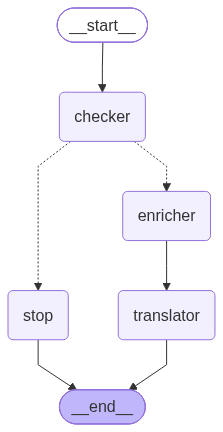

LangGraph pipeline compiled successfully.


In [18]:
# === Build the Graph ===
workflow = StateGraph(PipelineState)

# Add nodes
workflow.add_node("checker", checker_node)
workflow.add_node("enricher", enricher_node)
workflow.add_node("translator", translator_node)
workflow.add_node("stop", stop_node)

# Add edges

# Read the following like a flowchart:
# Start → checker
# After checker:
    # if gate returns "enricher" → go to enricher
    # if gate returns "stop" → go to stop
# Enricher → translator → end
# Stop → end

workflow.add_edge(START, "checker")   
workflow.add_conditional_edges(
    "checker", 
    validation_gate, 
    {"enricher": "enricher", "stop": "stop"}
)
workflow.add_edge("enricher", "translator")
workflow.add_edge("translator", END)
workflow.add_edge("stop", END)

# Compile the graph
marketing_chain = workflow.compile()

# Display the graph structure
display(Image(marketing_chain.get_graph().draw_mermaid_png()))
print("LangGraph pipeline compiled successfully.")

**Understanding the Graph Visualization:**

The diagram above shows our workflow as a flowchart. You should see:

```
START → checker → (conditional) → enricher → translator → END
                              ↘ stop → END
```

**Key things to notice:**
- The **conditional edge** from `checker` shows two possible paths
- Both `translator` and `stop` lead to `END` (the pipeline always terminates cleanly)
- The flow is deterministic once we know the validation result

**Running the Pipeline:**

To run this pipeline, we use `.invoke()` with an initial state:
```python
result = marketing_chain.invoke({"copy": "your marketing copy here"})
```

- We only need to provide the `copy` field; the other fields of the state start as empty/undefined
- LangGraph runs through the nodes, updating state at each step, as we defined in each node
- The final `result` contains all state fields after the pipeline completes, and we can print all of these individually as needed; we do this in the code below

### Step 5: Test the Pipeline

Let's test with the same two pieces of marketing copy we used earlier:
1. **Copy A** &mdash; Contains the required motto (should pass)
2. **Copy B** &mdash; Missing the motto (should stop at the gate)

#### Run the Following Cell

In [19]:
# Test Case A: Contains the motto (should pass validation)
copy_a = """At Cornell, we're advancing AI to do the greatest good. Our researchers tackle humanity's most pressing challenges through rigorous, interdisciplinary collaboration."""

display(Markdown("# Test Case A: Copy with Motto"))

# Run the pipeline
result_a = marketing_chain.invoke({"copy": copy_a})

output = f"""## Validation Result

**Passes:** {result_a['passes_validation']}

**Reasoning:** {result_a['reasoning']}

## Final Output

{result_a['final_output']}
"""
display(Markdown(output))

# Test Case A: Copy with Motto

## Validation Result

**Passes:** True

**Reasoning:** The copy contains the exact motto "to do the greatest good."

## Final Output

**English Version:**

At Cornell, we're advancing AI to do the greatest good. Our researchers tackle humanity's most pressing challenges through rigorous, interdisciplinary collaboration.

**Artificial Intelligence (AI)** is a branch of computer science focused on creating systems that can perform tasks typically requiring human intelligence. This includes areas such as machine learning, natural language processing, and robotics, with applications spanning many industries and academic fields.

---

**French Version:**

À Cornell, nous faisons progresser l’intelligence artificielle pour le plus grand bien. Nos chercheurs s’attaquent aux défis les plus pressants de l’humanité à travers une collaboration rigoureuse et interdisciplinaire.

**L’intelligence artificielle (IA)** est une branche de l’informatique axée sur la création de systèmes capables d’effectuer des tâches qui requièrent habituellement l’intelligence humaine. Cela inclut des domaines comme l’apprentissage automatique, le traitement du langage naturel et la robotique, avec des applications qui s’étendent à de nombreuses industries et disciplines académiques.


#### Run the Following Cell

In [20]:
# Test Case B: Missing the motto (should fail validation)
copy_b = """Cornell pushes the boundaries of AI through world-class research and ethical innovation. We're building intelligent systems that benefit everyone."""

display(Markdown("# Test Case B: Copy without Motto"))

# Run the pipeline
result_b = marketing_chain.invoke({"copy": copy_b})

output = f"""## Validation Result

**Passes:** {result_b['passes_validation']}

**Reasoning:** {result_b['reasoning']}

## Final Output

{result_b['final_output']}
"""
display(Markdown(output))

# Test Case B: Copy without Motto

## Validation Result

**Passes:** False

**Reasoning:** The motto "to do the greatest good" does not appear in the provided copy.

## Final Output

Pipeline stopped - validation failed


As you will see, the chain will be stopped, as the marketing copy does not contain "to do the greatest good." This is the expected behavior of the chain.

## Implement Blog Post Review Workflow With LangGraph

Now you'll implement the same **blog post review pipeline** using LangGraph. The scenario is the same as before: check for author credentials, then enhance with a call-to-action, then summarize for social media.

There are two code cells below. 

* In the first code cell, the state and node functions have been defined for you. 

* In the second code cell, your task is to complete the graph-building step by registering the four nodes to the workflow.

    For each node, call `blog_workflow.add_node()` with the following arguments:
    
    1. the node name (as a string)
    2. the function that implements that node
    
    **Hint:** Look at the edge definitions in the second code cell to see what node names are expected, e.g., <code>"checker"</code>, <code>"cta_enhancer"</code>, etc.

#### Run the Following Cell

In [21]:
# === Blog Post Pipeline State ===
class BlogState(TypedDict):
    post: str                    # The input blog post
    has_credentials: bool        # Result from checker
    reasoning: str               # Checker's explanation
    enhanced_post: str           # Output from CTA enhancer
    social_summary: str          # Output from summarizer


# === Node 1: Credential Checker ===
def blog_checker_node(state: BlogState):
    """Check if the post mentions author credentials."""
    prompt = f"""You are a blog post reviewer. Check if this post mentions the author's credentials 
(degrees, certifications, years of experience, or professional titles).

Post: {state['post']}

Respond with ONLY "PASS" or "FAIL" on the first line, then your reasoning on the second line."""
    
    response = llm.invoke(prompt)
    lines = response.content.strip().split('\n', 1)
    has_creds = lines[0].strip().upper() == "PASS"
    reasoning = lines[1].strip() if len(lines) > 1 else "No reasoning provided"
    
    return {"has_credentials": has_creds, "reasoning": reasoning}


# === Gate Function ===
def blog_validation_gate(state: BlogState):
    """Route based on credential check result."""
    if state["has_credentials"]:
        return "cta_enhancer"
    return "stop"


# === Node 2: CTA Enhancer ===
def blog_cta_node(state: BlogState):
    """Add a call-to-action to the post."""
    prompt = f"""Output this blog post verbatim, then add a compelling call-to-action at the end:

{state['post']}"""
    
    response = llm.invoke(prompt)
    return {"enhanced_post": response.content}


# === Node 3: Summarizer ===
def blog_summarizer_node(state: BlogState):
    """Create a social media summary."""
    prompt = f"""Create a social media summary with: a catchy headline, 2-3 sentence summary, and 3-5 hashtags:

{state['enhanced_post']}"""
    
    response = llm.invoke(prompt)
    return {"social_summary": response.content}


# === Stop Node ===
def blog_stop_node(state: BlogState):
    """Handle the case when validation fails."""
    return {"social_summary": "Pipeline stopped - no author credentials found"}


print("Blog pipeline nodes defined: blog_checker_node, blog_cta_node, blog_summarizer_node, blog_stop_node")

Blog pipeline nodes defined: blog_checker_node, blog_cta_node, blog_summarizer_node, blog_stop_node


In the code cell below, replace the line `raise NotImplementedError("Your code is missing.")` with your code. As this is an ungraded notebook, your work will not be submitted for grading. 

#### Enter Your Solution Then Run the Following Cell

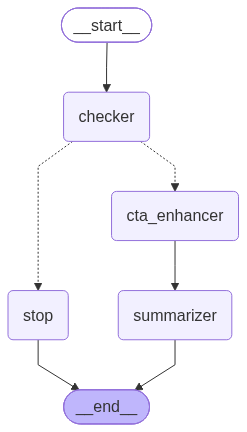

Blog post pipeline compiled successfully.


In [22]:
# === Build the Blog Post Pipeline Graph ===

blog_workflow = StateGraph(BlogState)

# Add nodes - register each node function with a name
# Hint: see the edges defined below to infer what the names should be/
# YOUR CODE HERE
blog_workflow.add_node("checker", blog_checker_node)
blog_workflow.add_node("cta_enhancer", blog_cta_node)
blog_workflow.add_node("summarizer", blog_summarizer_node)
blog_workflow.add_node("stop", blog_stop_node)
# END OF YOUR CODE

# Add edges - connect the nodes
blog_workflow.add_edge(START, "checker")
blog_workflow.add_conditional_edges(
    "checker", 
    blog_validation_gate, 
    {"cta_enhancer": "cta_enhancer", "stop": "stop"}
)
blog_workflow.add_edge("cta_enhancer", "summarizer")
blog_workflow.add_edge("summarizer", END)
blog_workflow.add_edge("stop", END)

# Compile the graph
blog_chain = blog_workflow.compile()

# Display the graph
display(Image(blog_chain.get_graph().draw_mermaid_png()))
print("Blog post pipeline compiled successfully.")

<details>
<summary style="text-align: left; background-color: #e3fbe3; color: #2a8bc6; padding: 10px 10px; cursor: pointer;" role="alert"><strong>✅ Solution</strong></summary>

<p style="padding: 10px;">
<pre>
blog_workflow.add_node("checker", blog_checker_node)
blog_workflow.add_node("cta_enhancer", blog_cta_node)
blog_workflow.add_node("summarizer", blog_summarizer_node)
blog_workflow.add_node("stop", blog_stop_node)
</pre>
</p>

</details>

### Test Your Pipeline

Run the cells below to test with the same blog posts.

#### Run the Following Cell

In [23]:
# Test Post A: Has author credentials (should pass)
post_a = """Understanding Neural Networks: A Beginner's Guide

By Dr. Sarah Chen, PhD in Computer Science with 15 years of experience in machine learning.

Neural networks are computational systems inspired by the human brain. They consist of 
interconnected nodes that process information in layers."""

display(Markdown("# Test Post A: With Credentials"))

# Run the pipeline
result_a = blog_chain.invoke({"post": post_a})

output = f"""## Credential Check Result

**Has Credentials:** {result_a['has_credentials']}

**Reasoning:** {result_a['reasoning']}

## Final Output

{result_a['social_summary']}
"""
display(Markdown(output))

# Test Post A: With Credentials

## Credential Check Result

**Has Credentials:** True

**Reasoning:** The post clearly mentions the author's PhD in Computer Science and 15 years of experience in machine learning.

## Final Output

🔍 Demystifying Neural Networks: Your First Step Into AI!  
Curious about how artificial intelligence really works? Dive into Dr. Sarah Chen's beginner-friendly guide to neural networks, where you'll discover how brain-inspired systems learn and process information. Ready to learn more? Subscribe to our newsletter for accessible ML tutorials and updates!

#NeuralNetworks #MachineLearning #AIForBeginners #TechEducation #LearnAI


#### Run the Following Cell

In [24]:
# Test Post B: No author credentials (should fail at gate)
post_b = """5 Tips for Better Sleep

Getting enough quality sleep is essential for your health and productivity. Here are 
five science-backed tips to improve your sleep tonight."""

display(Markdown("# Test Post B: Without Credentials"))

# Run the pipeline
result_b = blog_chain.invoke({"post": post_b})

output = f"""## Credential Check Result

**Has Credentials:** {result_b['has_credentials']}

**Reasoning:** {result_b['reasoning']}

## Final Output

{result_b['social_summary']}
"""
display(Markdown(output))

# Test Post B: Without Credentials

## Credential Check Result

**Has Credentials:** False

**Reasoning:** The post does not mention the author's credentials such as degrees, certifications, years of experience, or professional titles.

## Final Output

Pipeline stopped - no author credentials found


---

## Reflection: Prompt Chaining

You've now implemented the **prompt chaining** pattern using two different frameworks: OpenAI Agents SDK and LangGraph. Take a moment to reflect on what you've learned.

### Why Does This Pattern Work So Well?

Think back to the car painting analogy from the beginning of this module. You wouldn't try to prep, prime, paint, and inspect a car body all in one chaotic step. Each stage has its own tools, its own success criteria, and its own way of failing gracefully. The same principle applies to AI workflows.

When you broke the marketing copy task into checker, enricher, and translator steps, you gained something powerful: **visibility**. At any point, you can see exactly what the checker decided, why it decided that, and what the enricher added. If something goes wrong, you know exactly where to look.

### The Gate Is the Secret Ingredient

The most underrated part of prompt chaining is the gate. It seems simple &mdash; just an `if` statement! &mdash; but it solves a real problem: LLMs don't always give you what you want. By validating early and stopping the pipeline when something is off, you avoid wasting compute and, more importantly, you avoid passing garbage downstream where it becomes harder to debug.

Ask yourself: What happens in a pipeline without gates? The answer is that errors compound. A bad output from step 1 confuses step 2, which produces an even worse output for step 3. Gates let you fail fast and fail clearly.

### Framework Agnostic Thinking

Notice how similar the two implementations felt, even though the syntax was different. In the Agents SDK, you called `Runner.run()` sequentially. In LangGraph, you registered nodes and edges, then called `invoke()`. But the mental model was the same: define steps, connect them, add conditional logic where needed.

This is the real takeaway: Frameworks come and go. The OpenAI Agents SDK might evolve, LangGraph might change its API, and new tools will emerge. But if you understand the underlying pattern, you can adapt to any framework in an afternoon.

### When Should You Reach for Prompt Chaining?

Prompt chaining shines when:
- You can define the steps upfront (the workflow is deterministic)
- Each step has clear inputs, outputs, and success criteria
- You want explicit checkpoints where you can validate, log, or intervene
- Reliability matters more than flexibility

It's less ideal when:
- The steps depend heavily on what the LLM discovers during execution
- You need the agent to dynamically decide what to do next
- The workflow is exploratory rather than procedural

### Looking Ahead

Prompt chaining is just the first pattern in your toolkit. In the rest of this course, you'll learn about **routing**, letting the agent choose between different paths, **parallelization**, running multiple steps at once, and **orchestrator workflows**, having a central agent coordinate others.

Each pattern builds on the ideas you've learned here. The concepts of structured output, gates, and state management will keep showing up. Master them now, and the more advanced patterns will feel like natural extensions.

## Reflection: Prompt Chaining

Congratulations! You've now implemented the **prompt chaining** pattern using two different frameworks: OpenAI Agents SDK and LangGraph.

### Key Takeaways

1. **Decomposition**: Breaking complex tasks into smaller, focused steps makes each step easier to implement, test, and debug.
2. **Structured Output**: Using typed schemas enables programmatic decision making (gates) between steps.
3. **Gates**: Simple conditional logic prevents invalid or low-quality data from propagating through the pipeline.
4. **Framework Agnostic**: The pattern works the same way regardless of which framework you use.

### When to Use This Pattern

- **Content pipelines**: Validate → Transform → Publish
- **Data processing**: Extract → Clean → Analyze → Report
- **Document workflows**: Draft → Review → Approve → Finalize

### What's Next?

Prompt chaining is great when you know the exact sequence of steps in advance. But what if the agent needs to decide what to do based on the input? That's where we'll explore **routing** and other patterns in the upcoming sections.